In [40]:
import os
import json
import numpy as np
import re
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

micro_path = Path("output_micro")
mezo_path = Path("output_mezo")

robot_metric = {
    "micro": {},
    "meso_clusters": {},
    "meso_union": {}
}
clusters = [ [29, 34, 65, 72], 
            [17, 30, 41, 44, 54, 66, 79], 
            [12, 45, 73, 77, 83], 
            [18, 19, 27, 31, 50, 52, 62, 74, 78], 
            [11, 28, 32, 38, 42] ] 

all_mezo_robots = sorted(set(sum(clusters, []))) # имя объединённой папки 
union_folder = "robot_" + "_".join(map(str, all_mezo_robots))

def parse_level0(file_path):
    with open(file_path, 'r') as f:
        text = f.read()

    # Level 0
    level0_text = text.split("Level 1:")[0]

    # Solution [...]
    solutions = re.findall(r"Solution \d+:\s*\[([^\]]+)\]", level0_text)

    vectors = []
    for sol in solutions:
        nums = list(map(float, sol.split()))
        vectors.append(np.array(nums))

    return vectors


def get_solution_matrix(folder_path):
    txt_path = os.path.join(folder_path, "1_parts", "without_force", "obj_func_and_equations.txt")
    solutions = parse_level0(txt_path)
    return np.array(solutions)  # shape: (n_solutions, dim)

for folder in os.listdir(micro_path):
    if folder.startswith("robot_"):
        robot = int(folder.split("_")[1])
        path = os.path.join(micro_path, folder)

        mat = get_solution_matrix(path)  # (n, 2)

        # среднее по x,y → вектор (n,)
        sol_means = mat.mean(axis=1)

        robot_metric["micro"][robot] = [
            np.mean(sol_means),
            np.var(sol_means),
            len(sol_means)
        ]

for cluster in clusters:
    folder = "robot_" + "_".join(map(str, sorted(cluster)))
    path = os.path.join(mezo_path, folder)

    mat = get_solution_matrix(path) 
    mat = mat[:, :mat.shape[1] // 2]  # (n_solutions, 2 * len(cluster))
    # reshape → (n_solutions, n_robots, 2)
    mat = mat.reshape(mat.shape[0], len(cluster), 2)

    sol_means = mat.mean(axis=2)

    for i, robot in enumerate(cluster):
        robot_metric["meso_clusters"][robot] = [
            np.mean(sol_means[:, i]),
            np.var(sol_means[:, i]), 
            len(sol_means[:, i])
        ]

union_path = os.path.join(mezo_path, union_folder)
mat = get_solution_matrix(union_path)
mat = mat[:, :mat.shape[1] // 2]
n_robots = len(all_mezo_robots)

mat = mat.reshape(mat.shape[0], n_robots, 2)
sol_means = mat.mean(axis=2)

for i, robot in enumerate(all_mezo_robots):
    robot_metric["meso_union"][robot] = [
        np.mean(sol_means[:, i]),
        np.var(sol_means[:, i]),
        len(sol_means[:, i])
    ]
    
def compute_global_mean_and_total_var(level_dict):
    """
    level_dict: {robot_id: [mean, var, n_solutions]}
    """
    robot_ids = list(level_dict.keys())
    group_means = np.array([level_dict[r][0] for r in robot_ids])
    group_vars = np.array([level_dict[r][1] for r in robot_ids])
    group_sizes = np.array([level_dict[r][2] for r in robot_ids])

    # --- Общее среднее ---
    global_mean = np.sum(group_means * group_sizes) / np.sum(group_sizes)

    # --- Внутригрупповая дисперсия ---
    within_var = np.sum(group_vars * group_sizes) / np.sum(group_sizes)

    # --- Межгрупповая дисперсия ---
    between_var = np.sum(group_sizes * (group_means - global_mean)**2) / np.sum(group_sizes)

    # --- Полная дисперсия ---
    total_var = within_var + between_var

    return global_mean, total_var

micro_mean, micro_total_var = compute_global_mean_and_total_var(robot_metric["micro"])
meso_clusters_mean, meso_clusters_total_var = compute_global_mean_and_total_var(robot_metric["meso_clusters"])
meso_union_mean, meso_union_total_var = compute_global_mean_and_total_var(robot_metric["meso_union"])


print("Micro: mean =", micro_mean, "total_var =", micro_total_var)
print("Meso clusters: mean =", meso_clusters_mean, "total_var =", meso_clusters_total_var)
print("Meso union: mean =", meso_union_mean, "total_var =", meso_union_total_var)

Micro: mean = 0.8088755442901573 total_var = 2.3624358205750413
Meso clusters: mean = 0.8461159694055421 total_var = 0.044813329129605214
Meso union: mean = 1.0235632810666666 total_var = 0.21464877568908697


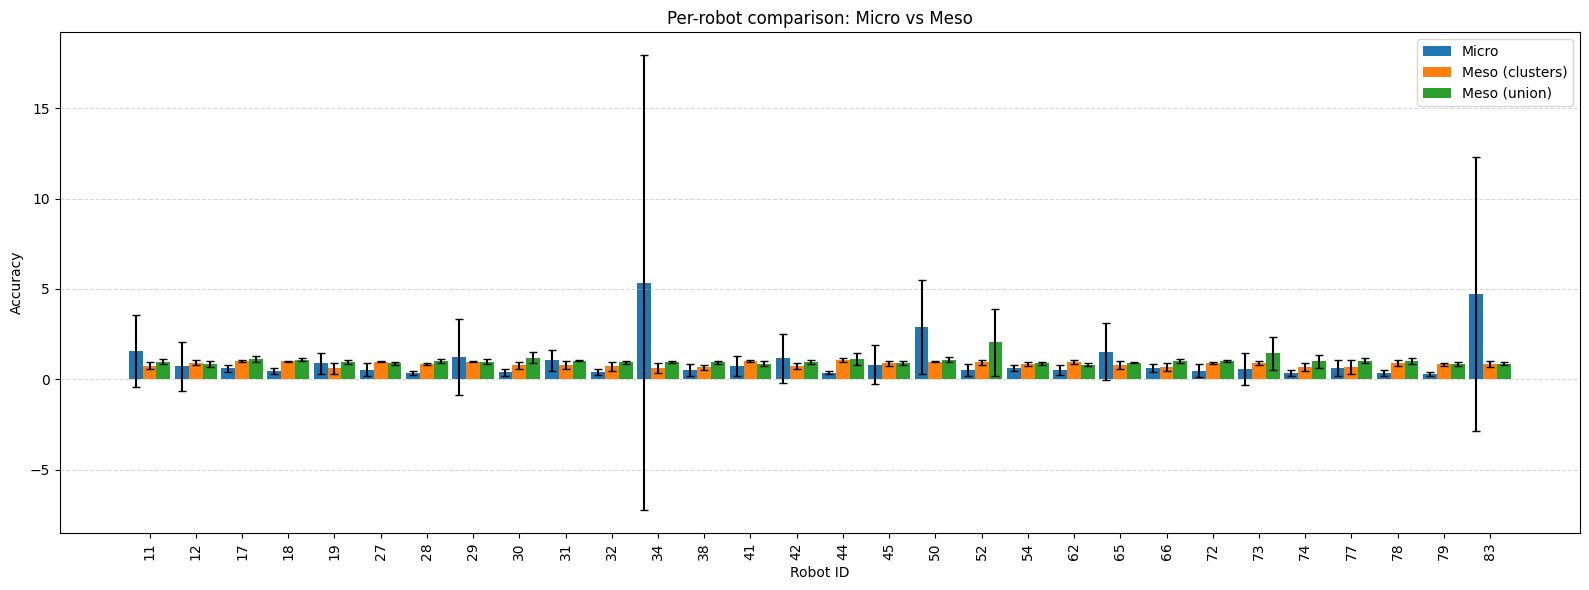

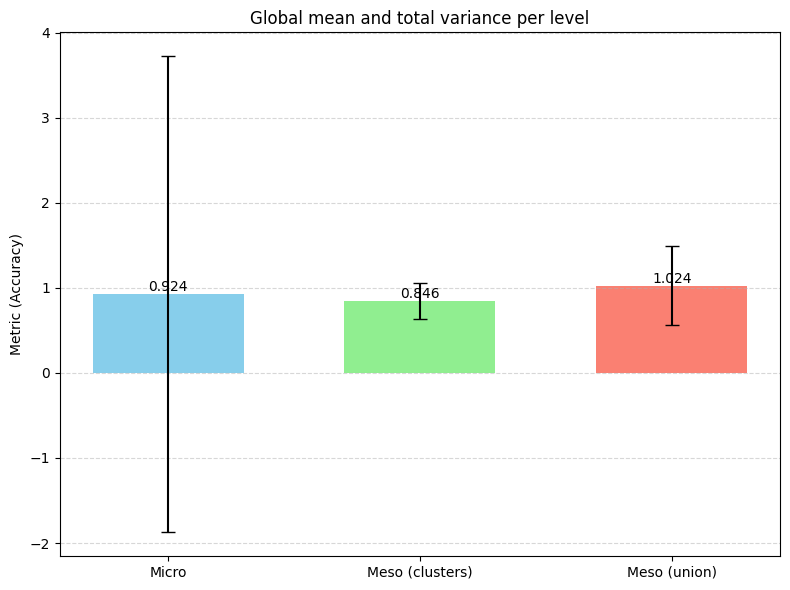

In [38]:
robots = sorted(robot_metric["micro"].keys())
x = np.arange(len(robots))
width = 0.3

micro_means = [robot_metric["micro"][r][0] for r in robots]
micro_vars = [robot_metric["micro"][r][1] for r in robots]

cluster_means = [robot_metric["meso_clusters"][r][0] for r in robots]
cluster_vars = [robot_metric["meso_clusters"][r][1] for r in robots]

union_means = [robot_metric["meso_union"][r][0] for r in robots]
union_vars = [robot_metric["meso_union"][r][1] for r in robots]

plt.figure(figsize=(16, 6))
plt.bar(x - width, micro_means, width,
        yerr=np.sqrt(micro_vars), capsize=3, label="Micro")
plt.bar(x, cluster_means, width,
        yerr=np.sqrt(cluster_vars), capsize=3, label="Meso (clusters)")
plt.bar(x + width, union_means, width,
        yerr=np.sqrt(union_vars), capsize=3, label="Meso (union)")

plt.xticks(x, robots, rotation=90)
plt.xlabel("Robot ID")
plt.ylabel("Accuracy")
plt.title("Per-robot comparison: Micro vs Meso")

plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()


levels = ["Micro", "Meso (clusters)", "Meso (union)"]
means = [micro_mean, meso_clusters_mean, meso_union_mean]
vars_ = [micro_total_var, meso_clusters_total_var, meso_union_total_var]

x = np.arange(len(levels))
width = 0.6

plt.figure(figsize=(8, 6))

plt.bar(x, means, width, yerr=np.sqrt(vars_), capsize=5, color=['skyblue', 'lightgreen', 'salmon'])

plt.xticks(x, levels, rotation=0)
plt.ylabel("Metric (Accuracy)")
plt.title("Global mean and total variance per level")

for i, v in enumerate(means):
    plt.text(x[i], v + 0.002, f"{v:.3f}", ha='center', va='bottom', fontsize=10)

plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

In [41]:

data = {
    "Level": ["Micro", "Meso (clusters)", "Meso (union)"],
    "Time (min)": [150, 178, 948]
}

df = pd.DataFrame(data)
print(df)

             Level  Time (min)
0            Micro         150
1  Meso (clusters)         178
2     Meso (union)         948
